
# Introduction

The Harvard Dialect Survey (Vaux et al.) asked tens of thousands of
respondents across the United States a list of questions about everyday
word choice, in the hope of mapping regional variation in American English
vocabulary in the way that traditional dialectologists mapped regional
variation in pronunciation. This lab works with a cleaned excerpt of that
survey: 47,471 respondents' answers to 67 "lexical" questions (word-choice
questions, as opposed to the survey's phonetic questions), together with
each respondent's self-reported city/state and a geocoded latitude and
longitude.

Aggregate, quantitative analysis of exactly this kind of data has a long
history in dialectology. Nerbonne and Kretzschmar's two review papers make
the case that pooling many small, individually noisy differences together
is what lets quantitative methods recover real dialect regions and describe how
sharp or gradual the boundaries between them actually are (Nerbonne and
Kretzschmar, 2003, 2006; full citations in the Bibliography).
That is the strategy of this lab. I first look at two individual survey
questions by hand, then recode every respondent's 67 answers into a single
binary vector and use dimension reduction and clustering to see whether
"aggregate" dialect regions emerge from the data, whether they match the
broad regions described in the dialectology literature (roughly a
North / Midland / South split, refined by coastal and inland differences),
and how stable those regions are to resampling and to the clustering
algorithm's random initialization.


In [1]:

import os

for _var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_var, "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
from pyreadr import read_r
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, fcluster

sns.set_theme(style="whitegrid", context="notebook", font_scale=0.9)
RNG_SEED = 215
np.random.seed(RNG_SEED)


# The Data {#data}

`lingData.txt` has one row per respondent ($n = 47{,}471$) and columns
`ID`, `CITY`, `STATE`, `ZIP`, the 67 lexical questions `Q050`-`Q121`, and a geocoded `lat`/`long`. Each `Q`
column holds an integer code for the option the respondent chose
(1, 2, 3, ...), with 0 meaning "no response"; the text of each numbered
option for each question is given in a companion file, `question_data.RData`.
`lingLocation.txt` aggregates the same 67 questions into $1^\circ\times
1^\circ$ latitude/longitude grid cells, with each cell's answers already
summed into one-hot counts. I use it only as a sanity check on my
aggregation and otherwise work with the respondent-level `lingData.txt`.

## Data Cleaning

Because this is a self-reported survey, several
cleaning decisions were necessary.

- **`STATE` is messy free text.** It takes 92 distinct raw values in the data, and many of them (e.g. `PL`, `00`, `IS`, `!L`) are not valid
  two-letter USPS codes. I decided so that any `STATE`-based summary below is restricted to the subset of rows whose `STATE` is a valid USPS code.
- **`lat`/`long` is missing for 1,020 respondents (2.1%)** whose city/state
  could not be geocoded. I drop these respondents only from analyses that
  require a location (maps) but kept them everywhere else.
- **206 further geocoded respondents (0.4%) fall outside the continental
  United States** -- true Alaska/Hawaii addresses, plus a handful of
  entries whose self-reported mainland city/state (e.g. "SanDiego, CA")
  was evidently geocoded to a Hawaiian ZIP code. I exclude these from maps
  of the continental United States, since the dialect regions I discuss
  below are mainland regions, but keep them in the non-geographic
  clustering analysis.
- **A `Q` value of 0 means "did not answer that question,"** As a judgement call, I choose to treat it as missing rather than as its own category.
- **1,040 respondents (2.2%) did not answer any of the 67 lexical questions at all** so I choose to drop them entirely.

In [ ]:

ling_data = pd.read_csv("../data/lingData.txt", sep=r"\s+")
ling_location = pd.read_csv("../data/lingLocation.txt", sep=r"\s+")
question_data = read_r("../data/question_data.RData")
quest_use = question_data["quest.use"]  # question wording, qnum 50-121

# Load US state boundaries for the map background (continental US only).
state_gdf = gpd.read_file("../data/shapefiles")
state_gdf = state_gdf[state_gdf["iso_a2"] == "US"]

CONUS_BOUNDS = dict(lon_min=-125, lon_max=-66, lat_min=24, lat_max=50)


def restrict_to_conus(df, lat_col="lat", lon_col="long"):
    """Drop rows with missing coordinates or coordinates outside CONUS."""
    out = df.dropna(subset=[lat_col, lon_col])
    b = CONUS_BOUNDS
    mask = (
        (out[lon_col] > b["lon_min"])
        & (out[lon_col] < b["lon_max"])
        & (out[lat_col] > b["lat_min"])
        & (out[lat_col] < b["lat_max"])
    )
    return out[mask]


# A Q value of 0 means "did not answer that question" so respondents who
# answered none of the 67 lexical questions are dropped entirely (count
# reported in Data Cleaning above).
q_cols = [c for c in ling_data.columns if c.startswith("Q")]
answered_any = (ling_data[q_cols] != 0).any(axis=1)
ling_clean = ling_data[answered_any].reset_index(drop=True)

# Valid two-letter USPS codes, used to restrict any STATE-based summary
# below to respondents whose free-text STATE field is actually valid.
usps_codes = {
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA", "HI", "ID",
    "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD", "MA", "MI", "MN", "MS",
    "MO", "MT", "NE", "NV", "NH", "NJ", "NM", "NY", "NC", "ND", "OH", "OK",
    "OR", "PA", "RI", "SC", "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV",
    "WI", "WY", "DC",
}


## Exploratory Data Analysis {#data-exploration}

I asked AI to list a few interesting questions for me and I picked: **Q50**, "What word(s) do you use to address a group of two
or more people?" (answers include *you*, *you guys*, *y'all*, *you all*, *yous/youse*, *you'uns*, *yins*), and **Q105**, "What is your generic term for a sweetened carbonated beverage?" (*soda*, *pop*, *coke*, *tonic*, *soft drink*, ...). Both are among the most famous individual dialect maps of American English, which makes them a useful place to start with


In [3]:

# Human-readable answer labels for the two questions used in the EDA, taken
# from question_data.RData (ans.50 / ans.105) rather than hard-coded blind.
def answer_label_map(qnum):
    """Return {integer code: answer text} for lexical question `qnum`."""
    ans_df = question_data[f"ans.{qnum}"]
    return {i + 1: text.strip() for i, text in enumerate(ans_df["ans"])}


q50_labels = answer_label_map(50)
q105_labels = answer_label_map(105)

eda = ling_data.copy()
eda["Q50_answer"] = eda["Q050"].map(q50_labels)
eda["Q105_answer"] = eda["Q105"].map(q105_labels)



Mapping the two most regionally distinctive answers to each question shows
that both individually define clear (and partly different) geographic
groups.


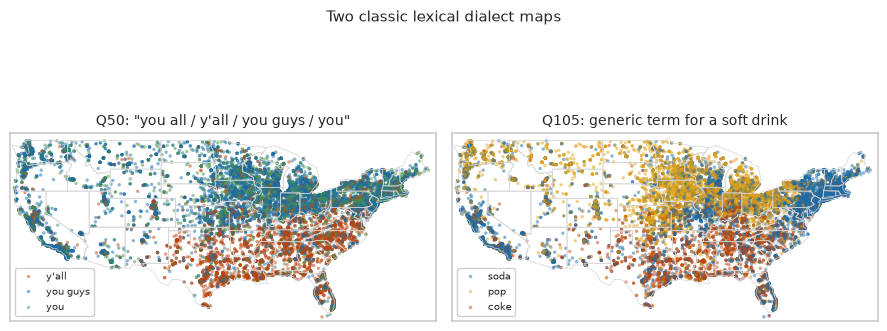

In [4]:

def plot_answer_map(ax, df, answer_col, categories, title, palette):
    """Scatter-plot respondents on a CONUS basemap, colored by answer."""
    state_gdf.boundary.plot(ax=ax, color="lightgray", linewidth=0.5)
    sub = restrict_to_conus(df.dropna(subset=[answer_col]))
    sub = sub[sub[answer_col].isin(categories)]
    sns.scatterplot(
        data=sub,
        x="long",
        y="lat",
        hue=answer_col,
        hue_order=categories,
        palette=palette,
        s=6,
        alpha=0.5,
        linewidth=0,
        ax=ax,
    )
    ax.set_xlim(CONUS_BOUNDS["lon_min"], CONUS_BOUNDS["lon_max"])
    ax.set_ylim(CONUS_BOUNDS["lat_min"], CONUS_BOUNDS["lat_max"])
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(title, fontsize=10)
    ax.legend(loc="lower left", fontsize=7, framealpha=0.9, title=None)


fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
plot_answer_map(
    axes[0],
    eda,
    "Q50_answer",
    ["y'all", "you guys", "you"],
    "Q50: \"you all / y'all / you guys / you\"",
    palette={"y'all": "#c1440e", "you guys": "#1b6ca8", "you": "#4a9349"},
)
plot_answer_map(
    axes[1],
    eda,
    "Q105_answer",
    ["soda", "pop", "coke"],
    "Q105: generic term for a soft drink",
    palette={"soda": "#1b6ca8", "pop": "#e0a319", "coke": "#c1440e"},
)
fig.suptitle("Two classic lexical dialect maps", fontsize=11)
fig.tight_layout()
plt.show()



For Q50, *y'all* is overwhelmingly a Southern answer, *you guys* dominates
the West Coast, the industrial Midwest, and much of the interior Northeast,
and the plain *you* is a minority answer concentrated in the Northeast and
Mid-Atlantic. For Q105, *soda* dominates the Northeast and the West Coast,
*pop* dominates a broad band of the Midwest, Great Lakes, and Mountain
West, and *coke* is used as a generic term for any soft drink across
almost the entire South. Both questions individually recover a recognizable
geographic pattern that is broadly consistent with the North/Midland/South
regions discussed in the dialectology literature, even though neither
question mentions geography at all.

Since both questions seem to be tracking the same underlying "which region
is this person from" variable, a natural next question is whether the
answer to one predicts the answer to the other, even with no geographic
information at all.


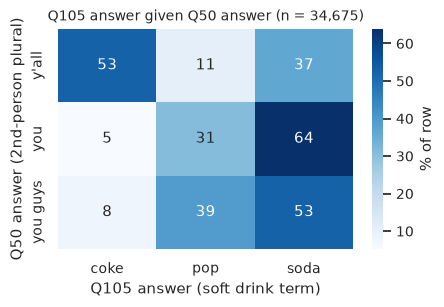

In [5]:

top_q50 = ["y'all", "you", "you guys"]
top_q105 = ["coke", "pop", "soda"]
paired = eda[eda["Q50_answer"].isin(top_q50) & eda["Q105_answer"].isin(top_q105)]
xtab = pd.crosstab(paired["Q50_answer"], paired["Q105_answer"], normalize="index")
xtab = xtab.loc[top_q50, top_q105]

fig, ax = plt.subplots(figsize=(4.6, 3.2))
sns.heatmap(
    xtab * 100,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    cbar_kws={"label": "% of row"},
    ax=ax,
)
ax.set_xlabel("Q105 answer (soft drink term)")
ax.set_ylabel("Q50 answer (2nd-person plural)")
ax.set_title(f"Q105 answer given Q50 answer (n = {len(paired):,})", fontsize=10)
fig.tight_layout()
plt.show()



The two questions are strongly associated: among respondents who say
*y'all*, 52.7% also say *coke* and only 10.7% say *pop*, while among
respondents who say the plain *you*, only 5.3% say *coke* and 63.9% say
*soda*; *you guys* respondents sit in between, with a plurality (52.7%)
saying *soda* and a substantial 39.3% saying *pop*. Knowing the answer to
one question is clearly informative about the other, even though the two
questions have nothing to do with each other semantically.
That is the idea I pursue for the rest of the report: if two individually
noisy lexical variables can already be partially explained by a shared
regional signal, pooling information across all 67 questions at once
should recover that regional structure far more clearly than any single
question or pair of questions can.



# Dimension Reduction

To use all 67 questions at once I first need a numeric encoding of each
respondent. The raw `Q` columns are *nominal* categorical codes: option 4
of Q50 (`you guys`) and option 9 (`y'all`) are just labels, and the
difference "9 minus 4 = 5" means nothing linguistically. Treating these
codes as ordinary numbers and feeding them straight into PCA (or any other
Euclidean-distance-based method) silently assumes an order and a scale that
isn't there, and different questions have very different numbers of
options (from 2 to 21), so a question with more options gets an
arbitrarily larger numeric range and can dominate the variance for no
substantive reason. I can see this failure mode directly: running PCA on
the raw `Q` columns gives a first "principal component" that explains 23%
of the variance, but 0.95 of its loading sits on a single question, Q59
(which happens to have 21 answer options, the most of any question in the
data) -- the correlation between a question's raw-code variance and its
number of answer options is 0.80. The first PC is not telling me about
regional dialect variation at all; it is telling me which question
happened to have the widest arbitrary numbering scheme.

Instead I follow the encoding suggested in the instructions and turn each
question into a set of binary indicators, one per answer option (a
respondent who chose option *k* of a question gets a 1 in that question's
*k*-th indicator column and a 0 everywhere else for that question; a
respondent who did not answer the question gets all zeros for it). Summed
over the 67 lexical questions this produces $p = 468$ binary columns per
respondent, matching the instructions.


In [6]:

def one_hot_encode_lexical(df, question_data):
    """One-hot encode every lexical Q column into a single wide 0/1 matrix.

    A value of 0 (no response) becomes an all-zero block for that question,
    matching the encoding used to build lingLocation.txt.
    """
    q_cols = [c for c in df.columns if c.startswith("Q")]
    blocks, col_names = [], []
    for col in q_cols:
        qnum = int(col[1:])
        n_options = question_data[f"ans.{qnum}"].shape[0]
        codes = df[col].to_numpy()
        block = np.zeros((len(df), n_options), dtype=np.int8)
        valid = (codes >= 1) & (codes <= n_options)
        rows = np.where(valid)[0]
        block[rows, codes[rows] - 1] = 1
        blocks.append(block)
        col_names += [f"{col}_{i + 1}" for i in range(n_options)]
    return np.hstack(blocks), col_names


X, bin_col_names = one_hot_encode_lexical(ling_clean, question_data)

# print(f"n = {X.shape[0]:,} respondents, p = {X.shape[1]} binary indicators")



## Scaling

`sklearn`'s `PCA` centers the data automatically. The remaining choice is
whether to also scale: many of the 468 one-hot indicator columns
correspond to rare answers chosen by a tiny fraction of respondents, while
others are chosen by close to half the sample, so standardizing every
column to unit variance (as in a correlation-matrix PCA) would treat them
as equally informative. The next cell checks what that actually does to
the columns and to the resulting components.


In [ ]:

Xf = X.astype(float)

# How lopsided are the column variances before any scaling?
col_std = Xf.std(axis=0)
rarest, widest = np.argmin(col_std), np.argmax(col_std)
# print(
    # f"Column std: {col_std[rarest]:.4f} ({bin_col_names[rarest]}, "
    # f"n={int(Xf[:, rarest].sum())}) to {col_std[widest]:.4f} "
    # f"({bin_col_names[widest]}, n={int(Xf[:, widest].sum()):,})"
# )
# print(
    # f"Unit-variance scaling inflates rarest column "
    # f"{1 / col_std[rarest]:.0f}x vs. {1 / col_std[widest]:.1f}x for widest."
# )

pca_centered = PCA(n_components=50, random_state=RNG_SEED)
Z50 = pca_centered.fit_transform(Xf)
evr_centered = pca_centered.explained_variance_ratio_

from sklearn.preprocessing import StandardScaler

Xs = StandardScaler().fit_transform(Xf)
pca_scaled = PCA(n_components=10, random_state=RNG_SEED)
pca_scaled.fit(Xs)
evr_scaled = pca_scaled.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(np.arange(1, 21), evr_centered[:20] * 100, "o-", label="centered, unscaled")
ax.plot(np.arange(1, 11), evr_scaled[:10] * 100, "s-", label="centered + scaled")
ax.set_xlabel("Principal component")
ax.set_ylabel("% variance explained")
ax.set_title("PCA on the binary-encoded survey: unscaled vs. scaled", fontsize=10)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# print(f"Top-5 PCs explain {evr_centered[:5].sum():.1%} of variance unscaled, vs. {evr_scaled[:5].sum():.1%} scaled.")
# print(f"Cumulative variance explained by top 20 PCs (unscaled): {evr_centered[:20].sum():.1%}")
# print(f"Cumulative variance explained by top 50 PCs (unscaled): {evr_centered.sum():.1%}")



Scaling is a bad idea here. The rarest column (`Q067_10`, chosen by just 4
of 46,431 respondents) has such tiny variance that standardizing it to
unit variance inflates it by roughly 108x, versus only 2x for the most
evenly split column . The data demonstrates that the top five components explain only about half as much variance scaled (7.2%) as unscaled (14.6%), because scaling spreads the
signal across more, noisier components instead of concentrating it in a
few interpretable ones. I therefore use centered, unscaled PCA throughout
the rest of the report.



Even with 50 components I only reach 55.7% of the total variance (33.0%
with 20 components). This is expected for high-dimensional, sparse survey
data where each of the 67 questions contributes its own largely independent
axis of variation, and it means no single pair of PCs should be expected to
show all of the interesting structure at once.


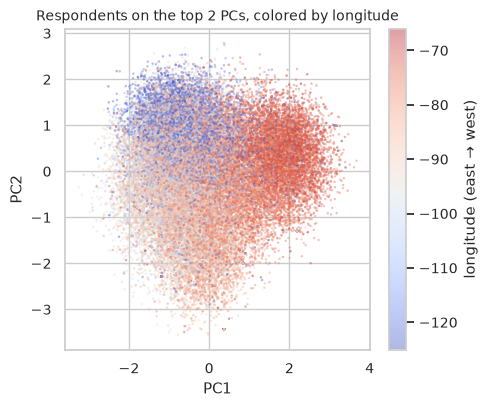

In [8]:

fig, ax = plt.subplots(figsize=(5, 4.2))
sc = ax.scatter(
    Z50[:, 0],
    Z50[:, 1],
    c=ling_clean["long"],
    cmap="coolwarm",
    # Clip the color scale to the continental US so that the handful of
    # Alaska/Hawaii outliers (see Data Cleaning) don't wash out the
    # gradient across the bulk of the (mainland) respondents.
    vmin=CONUS_BOUNDS["lon_min"],
    vmax=CONUS_BOUNDS["lon_max"],
    s=3,
    alpha=0.4,
    linewidth=0,
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Respondents on the top 2 PCs, colored by longitude", fontsize=10)
cb = fig.colorbar(sc, ax=ax)
cb.set_label("longitude (east → west)")
fig.tight_layout()
plt.show()



PC1 and PC2 alone show a diffuse cloud with only a weak color gradient which is
consistent with the low variance explained by any single component. If I
stopped here I would conclude "I don't see much," exactly the situation
the instructions anticipate, however changing the projection helps. Coloring by
longitude reveals a real, if noisy, East-West gradient along PC1 once I
look for it, and (as I show next) using more than 2 PCs as the input to a
clustering algorithm recovers much cleaner regional structure than either
PC1 or PC2 shows by itself. I use the top 20 PCs (33.0% of variance) as
the working low-dimensional representation for the clustering analysis
below, which balances keeping most of the structure PCA finds against
not re-introducing the noise in components far down the spectrum.



# Clustering

I cluster respondents in the 20-PC space described above using two
different algorithms: $k$-means, and Ward's hierarchical (agglomerative)
clustering.

## Choosing the number of clusters

I ran $k$-means for $k = 2, \dots, 8$ and evaluated both the within-cluster
sum of squares (inertia) and the silhouette score (on a random subsample of
5,000 respondents, for speed).


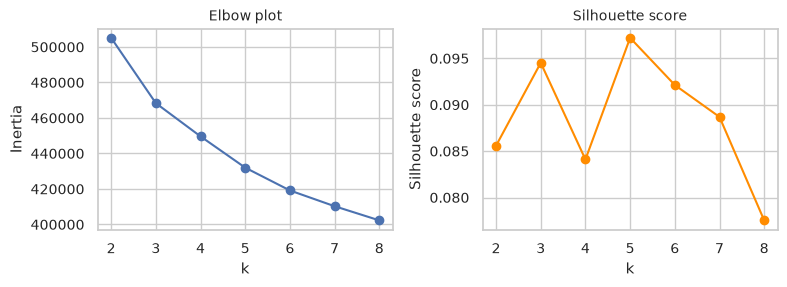

In [9]:

Z20 = Z50[:, :20]

rng = np.random.default_rng(RNG_SEED)
sil_idx = rng.choice(Z20.shape[0], 5000, replace=False)

ks = list(range(2, 9))
kmeans_by_k = {}
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RNG_SEED, n_init=10).fit(Z20)
    kmeans_by_k[k] = km
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Z20[sil_idx], km.labels_[sil_idx]))

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].plot(ks, inertias, "o-")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow plot", fontsize=10)
axes[1].plot(ks, sils, "o-", color="darkorange")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score", fontsize=10)
fig.tight_layout()
plt.show()


In [10]:

# Diagnose the smallest cluster found at k=5, to understand what a finer
# partition buys me (or doesn't) beyond k=3.
km5 = kmeans_by_k[5]
sizes5 = np.bincount(km5.labels_)
small_label = int(np.argmin(sizes5))

ling_clean["c5"] = km5.labels_
ling_clean["Q50_answer"] = ling_clean["Q050"].map(q50_labels)
small_cluster = ling_clean[ling_clean["c5"] == small_label]
yall_purity = (small_cluster["Q50_answer"] == "y'all").mean()

# print(f"k=5 cluster sizes: {sizes5}")
# print(f"Smallest cluster: {sizes5[small_label]} respondents")
# print(f"Fraction of that cluster answering 'y'all' to Q50: {yall_purity:.1%}")



Neither curve shows a single sharp elbow: this is itself informative. I choose $k=3$ for two reasons beyond the silhouette score. First, it is more interpretable and matches the coarse North/Midland-or-West/South structure suggested by the two-question EDA
above. Second, inspecting $k=5$ shows why more clusters is not obviously
better: one of its five clusters contains only 636 respondents, and every
single one of them (100%) answered *y'all* to Q50. This is a useful
illustration of a general disadvantage of $k$-means: because it only
minimizes Euclidean distance to $k$ cluster centers, it has no way to
distinguish "a genuinely new subpopulation" from "an unusually extreme
tail of an existing one," and will produce whichever partition is
requested regardless.


In [11]:

km3 = KMeans(n_clusters=3, random_state=RNG_SEED, n_init=10).fit(Z20)
ling_clean["cluster"] = km3.labels_
ling_clean["Q50_answer"] = ling_clean["Q050"].map(q50_labels)
ling_clean["Q105_answer"] = ling_clean["Q105"].map(q105_labels)

# Name each numeric k-means label by its most distinctive answer, so that
# "which integer is which region" doesn't depend on k-means' arbitrary
# label ordering.
yall_rate = ling_clean.groupby("cluster")["Q50_answer"].apply(lambda s: (s == "y'all").mean())
soda_rate = ling_clean.groupby("cluster")["Q105_answer"].apply(lambda s: (s == "soda").mean())
south_id = yall_rate.idxmax()
northeast_id = soda_rate.idxmax()
west_midwest_id = [c for c in range(3) if c not in (south_id, northeast_id)][0]
region_names = {south_id: "South", northeast_id: "Northeast", west_midwest_id: "West/Midwest"}
ling_clean["region"] = ling_clean["cluster"].map(region_names)



## What the three clusters look like

Mapping the three $k$-means clusters and looking at each cluster's most
distinctive answers to Q50 and Q105 shows that they align closely with
familiar dialect geography.


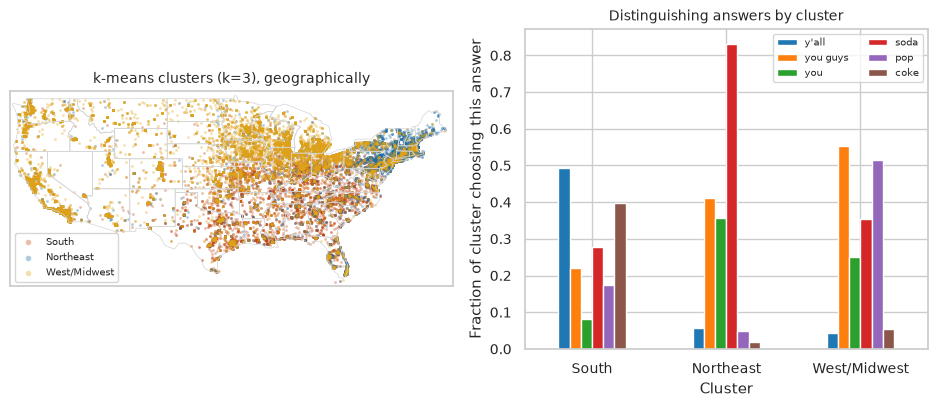

In [12]:

region_colors = {"South": "#c1440e", "Northeast": "#1b6ca8", "West/Midwest": "#e0a319"}

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2), gridspec_kw={"width_ratios": [1.1, 1]})

geo_clustered = restrict_to_conus(ling_clean)
state_gdf.boundary.plot(ax=axes[0], color="lightgray", linewidth=0.5)
for region, color in region_colors.items():
    sub = geo_clustered[geo_clustered["region"] == region]
    axes[0].scatter(sub["long"], sub["lat"], s=4, alpha=0.35, color=color, linewidth=0, label=region)
axes[0].set_xlim(CONUS_BOUNDS["lon_min"], CONUS_BOUNDS["lon_max"])
axes[0].set_ylim(CONUS_BOUNDS["lat_min"], CONUS_BOUNDS["lat_max"])
axes[0].set_aspect("equal")
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].set_xlabel("")
axes[0].set_ylabel("")
axes[0].set_title("k-means clusters (k=3), geographically", fontsize=10)
axes[0].legend(loc="lower left", fontsize=7, markerscale=2)

rates = pd.DataFrame(
    {
        "y'all": ling_clean.groupby("region")["Q50_answer"].apply(lambda s: (s == "y'all").mean()),
        "you guys": ling_clean.groupby("region")["Q50_answer"].apply(lambda s: (s == "you guys").mean()),
        "you": ling_clean.groupby("region")["Q50_answer"].apply(lambda s: (s == "you").mean()),
        "soda": ling_clean.groupby("region")["Q105_answer"].apply(lambda s: (s == "soda").mean()),
        "pop": ling_clean.groupby("region")["Q105_answer"].apply(lambda s: (s == "pop").mean()),
        "coke": ling_clean.groupby("region")["Q105_answer"].apply(lambda s: (s == "coke").mean()),
    }
).loc[["South", "Northeast", "West/Midwest"]]
rates.plot(kind="bar", ax=axes[1], color=sns.color_palette("tab10", 6))
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Fraction of cluster choosing this answer")
axes[1].set_title("Distinguishing answers by cluster", fontsize=10)
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

# Top states by respondent count within each region, restricted to valid
# USPS codes (see Data Cleaning), for the discussion below.
valid_state_rows = ling_clean[ling_clean["STATE"].isin(usps_codes)]
for region in ["South", "Northeast", "West/Midwest"]:
    top5 = valid_state_rows.loc[valid_state_rows["region"] == region, "STATE"].value_counts().head(5)
    # print(f"{region} top states: {', '.join(top5.index)}")

# print()
# print("Distinguishing-answer rates by region:")
# print((rates * 100).round(1))


The **South** cluster's top states by respondent count are TX, MO, VA, KS,
and OH; 49.4% of its members say *y'all* and 39.7% say *coke*. The
**West/Midwest** cluster is the largest and most geographically spread out
(top states CA, IL, MI, WA, WI); 55.3% say *you guys* and 51.6% say *pop*
which aligns with the general American pattern. The **Northeast** cluster's
top states are NY, PA, MA, NJ, and CT; 83.1% say *soda*, easily its most
distinctive feature, and it has the highest rate (35.8%) of the plain
*you*. All of this lines up closely with the individual Q50/Q105 maps from
the Exploratory Data Analysis section, but now derived automatically from
all 67 questions at once rather than hand-picked from two.

## A second clustering method: hierarchical clustering

As a second method I ran Ward's hierarchical clustering, which builds a
full dendrogram by repeatedly merging the two clusters whose merger
increases within-cluster variance the least. Hierarchical clustering scales
poorly to $n = 46{,}431$ points (its distance computation is $O(n^2)$), so
I fit it on a random subsample of 3,000 respondents and cut the resulting
dendrogram at 3 clusters, then compared the result to $k$-means fit on the
same subsample.


In [13]:

sub_idx = rng.choice(Z20.shape[0], 3000, replace=False)
Zsub = Z20[sub_idx]

link = linkage(Zsub, method="ward")
hc_labels = fcluster(link, t=3, criterion="maxclust")
km_sub = KMeans(n_clusters=3, random_state=RNG_SEED, n_init=10).fit(Zsub)

ari_methods = adjusted_rand_score(hc_labels, km_sub.labels_)
# print(f"Adjusted Rand Index, Ward vs. k-means (same 3,000-point subsample): {ari_methods:.3f}")
# print(f"Ward cluster sizes: {np.bincount(hc_labels)[1:]}")
# print(f"k-means cluster sizes: {np.bincount(km_sub.labels_)}")



The two methods agree far more than chance (Adjusted Rand Index 0.46 -- 1.0
would be perfect agreement, 0.0 is what two random partitions would give)
but clearly do not agree perfectly. This moderate-but-incomplete agreement,
together with the lack of a sharp elbow above, is itself evidence for one
of the questions the instructions raise: the boundaries between these three
regions look more like a continuum than three cleanly separated islands,
which matches how dialectologists usually describe American English
regions.

Each method has its own advantages and disadvantages for this application.
$k$-means scales to the full $n=46{,}431$ respondents, is fast, and
directly optimizes an interpretable objective, but it must be told $k$ in advance. Ward's method does not require choosing $k$ up front and its merge history is a useful diagnostic in its own right, but it does not scale to the full dataset and, because it greedily merges from the bottom up, an early bad merge cannot be undone later.



# Stability of findings to perturbation

I focus on the $k$-means, $k=3$ result and ask how much it changes under
two kinds of perturbation: (1) re-running $k$-means from different random
starting points, and (2) re-running it on random 80% subsamples of the
data. In both cases I measure agreement between two clusterings with the Adjusted Rand Index (ARI), which is 1.0 for identical partitions and about 0.0 for two random
partitions.


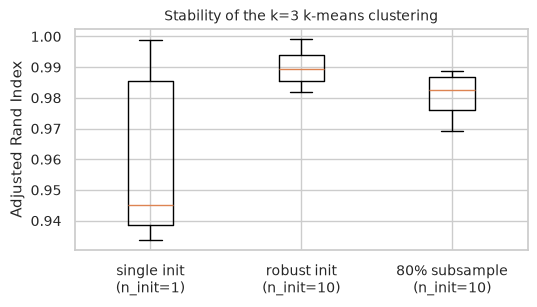

In [14]:

# (1) Sensitivity to random initialization: a single k-means run (n_init=1)
# from five different random seeds, compared pairwise.
single_init_labels = [
    KMeans(n_clusters=3, random_state=s, n_init=1).fit(Z20).labels_ for s in range(5)
]
single_init_aris = [
    adjusted_rand_score(single_init_labels[i], single_init_labels[j])
    for i in range(5)
    for j in range(i + 1, 5)
]

# The same comparison, but each run first does 10 internal restarts
# (n_init=10, scikit-learn's k-means++ default) before returning its best
# solution -- this is what I actually used to produce the k=3 result above.
robust_init_labels = [
    KMeans(n_clusters=3, random_state=s, n_init=10).fit(Z20).labels_ for s in range(5)
]
robust_init_aris = [
    adjusted_rand_score(robust_init_labels[i], robust_init_labels[j])
    for i in range(5)
    for j in range(i + 1, 5)
]

# (2) Subsampling stability: cluster two independent random 80% subsamples
# and compare labels on the respondents common to both.
boot_aris = []
n = Z20.shape[0]
for b in range(10):
    idx_a = rng.choice(n, int(0.8 * n), replace=False)
    idx_b = rng.choice(n, int(0.8 * n), replace=False)
    common = np.intersect1d(idx_a, idx_b)
    km_a = KMeans(n_clusters=3, random_state=b, n_init=10).fit(Z20[idx_a])
    km_b = KMeans(n_clusters=3, random_state=b + 100, n_init=10).fit(Z20[idx_b])
    # Look up, for each respondent common to both subsamples, its cluster
    # label in each of the two independent clusterings.
    labels_a = km_a.labels_[pd.Index(idx_a).get_indexer(common)]
    labels_b = km_b.labels_[pd.Index(idx_b).get_indexer(common)]
    boot_aris.append(adjusted_rand_score(labels_a, labels_b))

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.boxplot(
    [single_init_aris, robust_init_aris, boot_aris],
    tick_labels=["single init\n(n_init=1)", "robust init\n(n_init=10)", "80% subsample\n(n_init=10)"],
)
ax.set_ylabel("Adjusted Rand Index")
ax.set_title("Stability of the k=3 k-means clustering", fontsize=10)
fig.tight_layout()
plt.show()

# print(f"Single-init ARI: mean={np.mean(single_init_aris):.3f}, min={np.min(single_init_aris):.3f}")
# print(f"Robust-init (n_init=10) ARI: mean={np.mean(robust_init_aris):.3f}, min={np.min(robust_init_aris):.3f}")
# print(f"80%-subsample ARI: mean={np.mean(boot_aris):.3f}, sd={np.std(boot_aris):.3f}")



The clustering is quite stable. A single, un-restarted $k$-means run
already agrees with another single run 0.93-0.99 of the time (mean ARI
0.96); using scikit-learn's default of 10 internal restarts per fit (as I
did throughout the report) tightens this further to a mean of 0.99.
Clustering random 80% subsamples of the data and comparing labels on the
overlapping respondents gives a similarly high and tight distribution of
ARIs (mean 0.98, sd 0.006). In other words, the three-region structure is
not an artifact of a lucky random initialization or of the particular
46,431 respondents I happened to have. After the stability check, it reappears reliably under both kinds of perturbation I tried, which gives me much more confidence in the
geographic story above than the (fairly low) silhouette scores alone would
suggest. This is consistent with my reading of the South/Northeast/West-Midwest
split as a real, broad regional grouping and not noise.



# Conclusion

Running through the three realms (data, algorithms and analysis, and
future data) is a useful way to check how much weight these results can
actually carry. Start with the data itself: this is a convenience sample.
People opted into a web survey, so respondents skew toward internet users
willing to sit through a dialect quiz, and the geocoding only places
someone at their ZIP code's centroid, not their real address. The 92
distinct raw `STATE` values documented in Data Cleaning are a reminder
that some of it is simply typed wrong. None of that invalidates the
analysis, but it does mean the clusters describe this particular,
imperfect sample rather than the U.S. population at large.

That caveat carries over to the algorithms and analysis: the moderate
agreement between $k$-means and Ward's method, together with the lack of a
sharp elbow in either, points toward a real but graded regional gradient
rather than three hard-edged boundaries. I'd treat the three clusters as a
reasonable summary of that gradient, not as ground truth.

For future data and decisions, I'd treat this dataset as a snapshot. It is
useful for describing lexical variation around when the survey ran, but
not something I'd want to build a decision on without revisiting it.
Language use drifts over time and the sample isn't demographically
representative, so I'd be wary of reusing these exact cluster boundaries
for something like regional marketing copy, or any other decision that
needs current, representative estimates, without re-validating on fresher
data first.

The most direct reality check I can think of is to hold out some of the
67 questions, refit the clustering on the rest, and see whether the
resulting respondent-level clusters still line up with the held-out
questions the way the Q50/Q105 relationship in the Exploratory Data
Analysis section suggests they should. I'd also want to rerun the whole
pipeline on `lingLocation.txt`'s grid-cell aggregates, as an independent
check that the person-level conclusions aren't an artifact of how I
cleaned and encoded `lingData.txt`. I didn't get to either of these, but
they're the first things I'd try with more time, along with a
soft-clustering approach.


# Academic Honesty
I value UC Berkeley's standards of academic integrity, as well as academic integrity more broadly. I believe honesty is essential to academic research because research depends on others being able to trust how ideas, analyses, and conclusions were produced. All analyses and conclusions in this report are my own. Whenever I received ideas or consultation from other students, outside resources, or AI tools, I have acknowledged their use in the relevant part of the report. 

I used LLM tools in the following ways:

- **Report writing:** I used generative AI to polish grammar and sentence flow in
  already-written paragraphs in the report. I did not ask it to generate paragraphs from bullet points or
  rewrite sections wholesale. All edits were reviewed and are reflected in
  the final wording.
- **Code:**
  - I did not use LLM to generate any code from scratch in this lab.
  - I used AI to help organized so my code follows the guidelines and wrote explanation/documentation for my code. I retyped and verified the suggested code myself before incorporating it.



# Bibliography

- J. Nerbonne and W. Kretzschmar Jr. (2003). Introducing computational
  techniques in dialectometry. *Computers and the Humanities*, 37(3),
  245-255.
- J. Nerbonne and W. Kretzschmar Jr. (2006). Progress in dialectometry:
  Toward explanation. *Literary and Linguistic Computing*, 21(4), 387-397.
- Vaux, B. and Golder, S. *The Harvard Dialect Survey*. Harvard University
  Linguistics Department.
